In [1]:
import matplotlib.pyplot as plt
import torch
from cryosim.plotting_tools import plot3d
from cryosim.imagegenerator import MicrographGenerator
from rich.progress import track
from cryosim.pdbtools import PDB
from cryosim.potential import PotentialBuilder

%load_ext autoreload
%autoreload 2

In [2]:
# fetch pdb file
pdb_code = "6bdf"
assembly = True  # True: fetches assembly. False: fetches subunit. int: fetches specific assembly #int
pdb = PDB(pdb_code, assembly=True, savefolder="../pdb-data/")

Assemblies available: 1
6bdf: Fetching default Biological Assembly 1
File already exists: ../pdb-data/6bdf-assembly1.cif, skip fetching.


Output()

In [3]:
# Samples 3D scattering potential onto specified grid
n = 256  # number of pixels per axis
dx = 1  # angstrom, pixel size.
device = "cpu"
pb = PotentialBuilder(n, dx, pdb.atomic_numbers).to(device)

In [4]:
with torch.no_grad():
    V = pb(pdb.coordinates).clone()

Output()

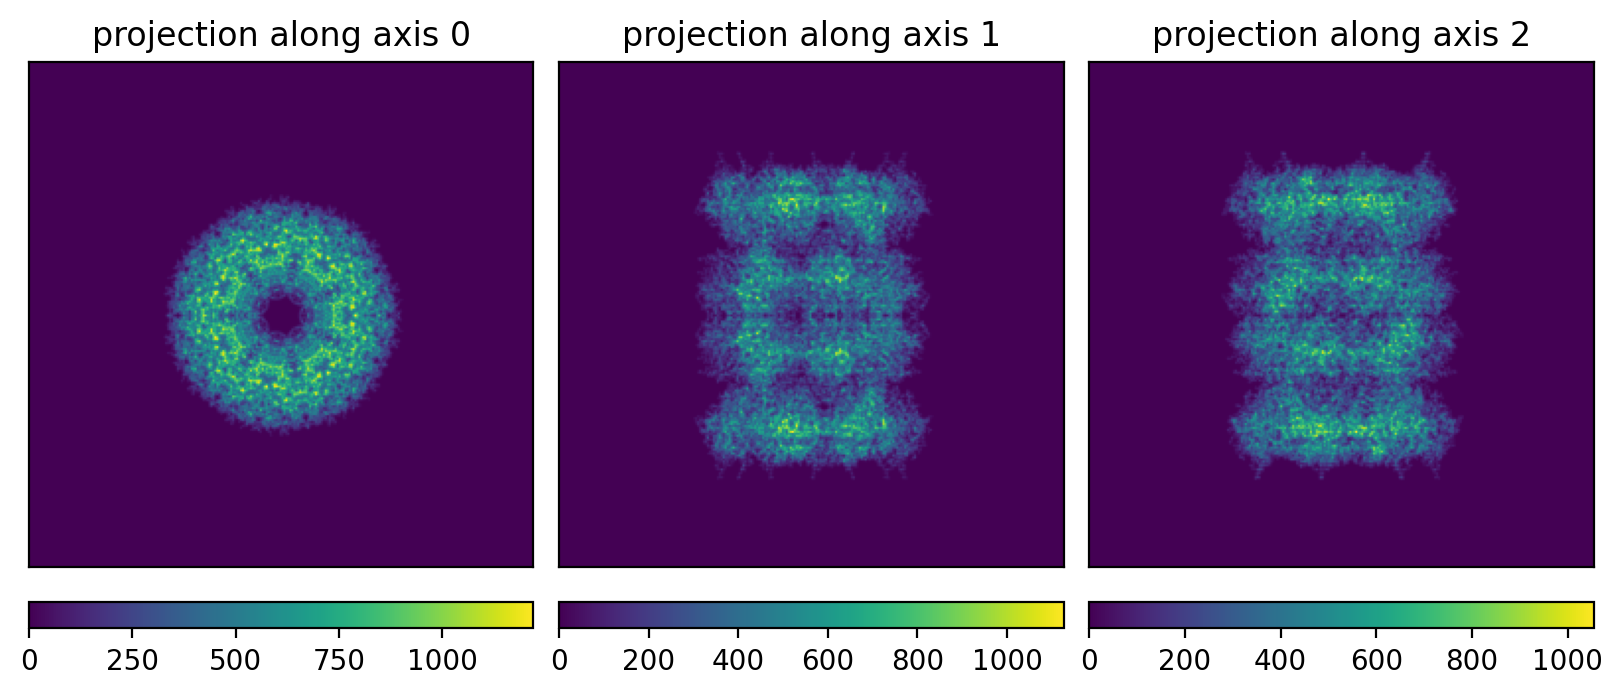

In [5]:
plot3d(V)

## Micrograph class

In [63]:
n_micrographs = 1
energy = 300  # keV
dose_per_angstrom = 20  # e-/A^2
Cs = 2e7  # angstrom. Sherical aberration, typical values are 1-3 mm.
alpha = 0.1
micrograph_size = 2048

In [64]:
# random defocus
defocus_min = 5000  # angstrom
defocus_max = 15000  # angstrom
defocus_A = torch.rand(n_micrographs) * (defocus_max - defocus_min) + defocus_min


# Can include 'cs', 'dfu', 'dfv', 'dfang', 'tiltx', 'tilty', 'phaseshift', 'trefoil1, 'trefoil2'
ctf_params = {
    "cs": torch.tensor([Cs] * n_micrographs),
    "dfu": defocus_A,
}

In [65]:
device = "cuda:0"  # choose cpu if you run out of cuda memory.

In [76]:
# Use multislice, holography, poisson and random_choice to obtain close to experimental conditions.
scattering_model = "multislice"  # 'multislice', 'firstborn', 'projection', 'ctf'
aberration_model = "holography"  # 'holography' or 'ctf'

noise_model = "poisson"  # 'poisson' or None
# noise_model = None

ice_model = "iterative"  # 'randomchoice' for fast & inaccurate, 'iterative' for slow & accurate, or None
# ice_model = None

ice_thickness = 500  # angstroms, set to 0 for minimum ice thickness = particle box size

crowd_min_distance = pdb.max_diameter  # angstroms, set to None for no crowding
# crowd_min_distance = None

crowd_max_distance_z = None  # if None, defaults to ice_thickness which would result in too many particles above each other.

pad_fft = False  # True to avoid edge artifacts when if crowd_min_distance is not None
# pad_fft = True

chunk_size = 8  # set to None for no chunking (cuda memory might exceed)

scaling_factor = 0.2

model = MicrographGenerator(
    V * scaling_factor,
    micrograph_size,
    dx,
    ctf_params,
    energy,
    dose_per_angstrom,
    ice_model=ice_model,
    ice_thickness=ice_thickness,
    scattering_model=scattering_model,
    aberration_model=aberration_model,
    noise_model=noise_model,
    klim=None,
    alpha=alpha,
    crowd_min_distance=crowd_min_distance,
    crowd_max_distance_z=crowd_max_distance_z,
    pad_fft=pad_fft,
    chunk_size=chunk_size,
    move_to_cpu=True,
).to(device)

In [ ]:
idx = torch.arange(n_micrographs)
images = []
batchsize = 1  # set higher or lower for faster/slower generation.
with torch.no_grad():
    for i in track(
        range(0, n_micrographs, batchsize), description="Generating micrographs"
    ):
        image = model(idx[i : i + batchsize])
        images.append(image.detach().cpu())

images = torch.concat(images, dim=0)
images.shape

Output()

In [ ]:
z = torch.linspace(0, 500, 200)
plt.figure(dpi=200)
plt.plot(z, model.crowd.z_distribution)
plt.xlabel("z (A)")
plt.ylabel("Probability of accepting duplicate (a.u.)")

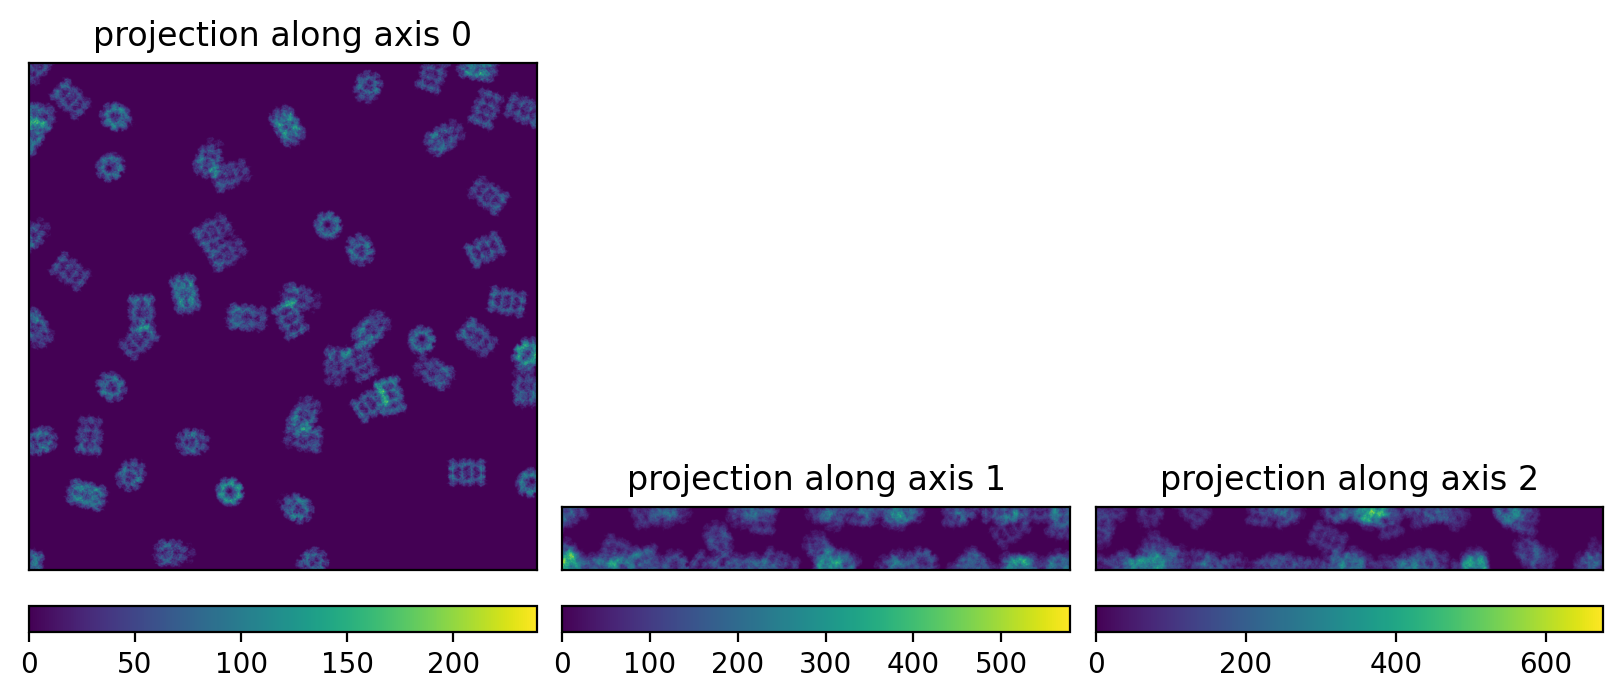

In [82]:
plot3d(model.vols.detach().cpu())

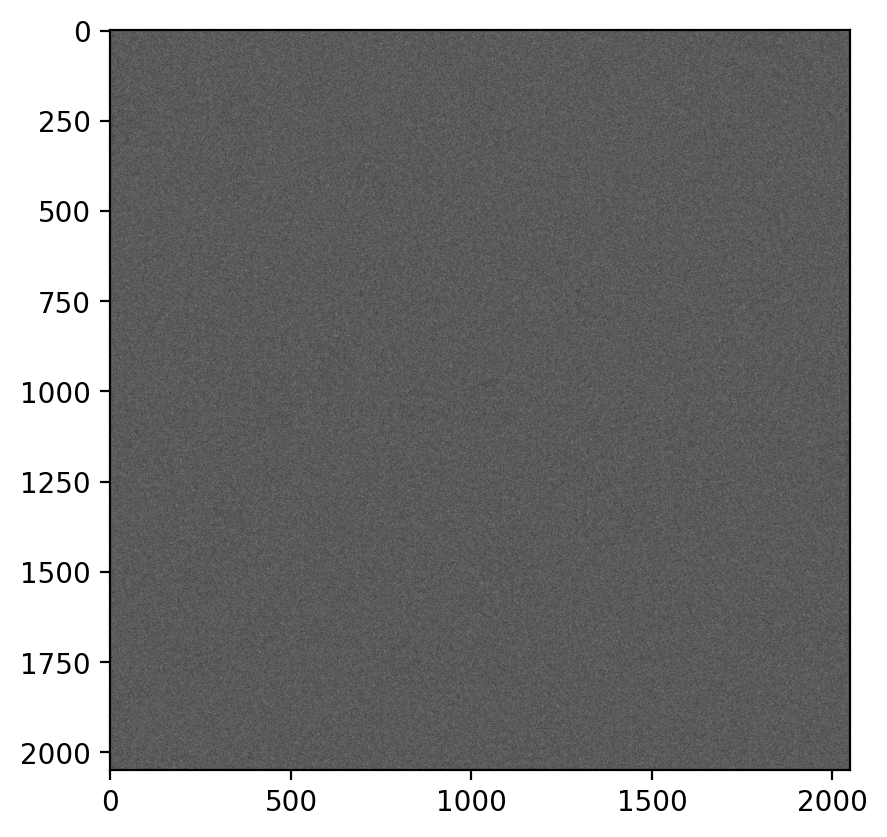

In [81]:
plt.figure(dpi=200)
plt.imshow(images[0], cmap="grey")

In [ ]:
# import mrcfile

In [ ]:
# for i, im in enumerate(images):
#     with mrcfile.new(f'/scratch/loh/joel/czii/micrograph{i}.mrcs', overwrite=True) as mrc:
#         mrc.set_data(im.numpy())

In [ ]:
# def create_particle_starfile(
#     particles,
#     rotations=None,
#     translations=None,
#     alpha=0.1,
#     folderpath='',
#     energy=None,
#     dx=None,
#     starfilename='particles',
#     mrcfilename=None,
#     ctf_params=None
# ):

In [ ]:
# fig, axes = plt.subplots(1, 5, dpi=200, constrained_layout=True, figsize=(10, 5))
# for i, ax in enumerate(axes.ravel()):
#     im = ax.imshow(images[i], cmap="grey")
#     ax.set(xticks=[], yticks=[])
#     ax.set_title(f"Defocus: {ctf_params[i,2]/10000:.2f} $\mu$m")
#     fig.colorbar(im, ax=ax, location="bottom")
# plt.show()